In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

def residualize(y, X):
    reg = LinearRegression().fit(X, y)
    return y - reg.predict(X)

In [3]:
patientsData = pd.read_csv('FWResults.csv')

In [6]:

var = 'Final_Score_average'

# Fit the model
model = smf.mixedlm(
    formula=f"Q('{var}') ~ pSN_FW+ AGE_Baseline",
    data=patientsData,
    groups=patientsData["SubjectID"],
    re_formula='~1'
)

result = model.fit(reml=True)
print(result.summary())

                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q('Final_Score_average')
No. Observations: 47      Method:             REML                    
No. Groups:       34      Scale:              0.5352                  
Min. group size:  1       Log-Likelihood:     -74.8171                
Max. group size:  2       Converged:          Yes                     
Mean group size:  1.4                                                 
-------------------------------------------------------------------------
                Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        0.322       1.912     0.168    0.866    -3.426     4.070
pSN_FW          16.408       8.108     2.024    0.043     0.516    32.300
AGE_Baseline    -0.014       0.032    -0.449    0.653    -0.077     0.049
Group Var        1.269       1.160                                       



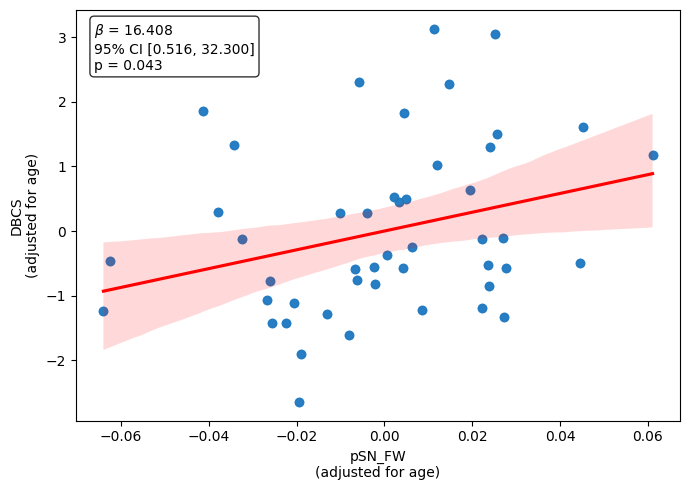

In [7]:
var = 'Final_Score_average'

age = patientsData[["AGE_Baseline"]].values
brain_res =residualize(patientsData["pSN_FW"].values, age)
kinematic_res = residualize(patientsData["Final_Score_average"].values, age)


beta = result.params['pSN_FW'] 
p = result.pvalues['pSN_FW'] 
ci = result.conf_int().loc['pSN_FW'].values 

# Step 2 — regression line from your LMM beta
x_line = np.linspace(brain_res.min(), brain_res.max(), 100)
y_line = beta * x_line  # your beta

# Step 3 — plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(brain_res, kinematic_res, alpha=1, color="#378ADD", label="Observations")
# ax.plot(x_line, y_line, color="#D85A30", linewidth=2, label=f"β = {beta:.2f}\np = {p:.3f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
# ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
# ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

sns.regplot(x=brain_res, y=kinematic_res, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=ax)

ax.set_xlabel("pSN_FW\n(adjusted for age)")
ax.set_ylabel("DBCS\n(adjusted for age)")
ax.text( 0.03, 0.97, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# ax.legend()
plt.tight_layout()
plt.show()